In [1]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
etf_tickers = ["XLK", "XLF", "XLE", "XLV", "XLI", "XLY", "XLP", "XLB", "XLU", "XLRE", "XLC"]
data = yf.download(etf_tickers, period = "10y")["Close"]
data

[*********************100%***********************]  11 of 11 completed


Ticker,XLB,XLC,XLE,XLF,XLI,XLK,XLP,XLRE,XLU,XLV,XLY
Date,,,,,,,,,,,
2016-06-02,19.328028,NaN,22.264725,16.071152,47.038727,19.749540,40.728252,22.681873,17.931749,61.374485,35.827522
2016-06-03,19.491617,NaN,22.178072,15.842038,46.996750,19.704697,40.988445,22.784250,18.215460,61.171402,35.593559
2016-06-06,19.692019,NaN,22.668022,15.936385,47.441628,19.740582,41.034359,22.795635,18.190001,61.501408,35.683563
2016-06-07,19.700193,NaN,23.181316,15.902692,47.668247,19.821291,40.988445,22.814114,18.175440,61.120621,35.728550
2016-06-08,19.814707,NaN,23.127979,15.916162,47.970425,19.861656,41.233337,22.923616,18.284567,61.332199,35.769035
...,...,...,...,...,...,...,...,...,...,...,...
2026-05-26,50.990002,115.550003,57.849998,51.849998,174.300003,185.139999,83.629997,44.709999,45.330002,148.509995,119.449997
2026-05-27,51.180000,116.260002,56.990002,51.419998,174.300003,184.429993,84.580002,44.630001,45.139999,148.789993,121.550003
2026-05-28,51.360001,116.669998,56.950001,51.270000,173.800003,186.850006,84.430000,44.410000,44.630001,150.880005,122.059998


In [3]:
returns = data.pct_change()
returns = returns.dropna(how = "any")
returns

Ticker,XLB,XLC,XLE,XLF,XLI,XLK,XLP,XLRE,XLU,XLV,XLY
Date,,,,,,,,,,,
2018-06-20,-0.003248,0.012410,0.004415,-0.002559,0.000683,0.002100,0.000980,0.010794,0.000797,0.002122,0.004742
2018-06-21,-0.010635,-0.006129,-0.018516,-0.002933,-0.012555,-0.007684,0.001956,0.005967,0.003385,-0.005762,-0.007123
2018-06-22,0.014563,0.004377,0.019951,-0.004779,0.003455,-0.003238,0.008202,0.008742,0.006944,0.004494,-0.001704
2018-06-25,-0.015551,-0.020598,-0.020093,-0.010713,-0.012671,-0.020763,0.005036,-0.002476,0.016552,-0.009184,-0.021739
2018-06-26,0.003819,0.001658,0.012629,-0.003361,0.003767,0.004039,-0.004240,0.005275,0.001163,-0.003089,0.007162
...,...,...,...,...,...,...,...,...,...,...,...
2026-05-26,0.013919,0.000780,-0.027568,-0.001733,0.014729,0.026332,-0.013797,0.003366,-0.000441,-0.009207,0.002265
2026-05-27,0.003726,0.006145,-0.014866,-0.008293,0.000000,-0.003835,0.011360,-0.001789,-0.004192,0.001885,0.017581
2026-05-28,0.003517,0.003527,-0.000702,-0.002917,-0.002869,0.013122,-0.001773,-0.004929,-0.011298,0.014047,0.004196


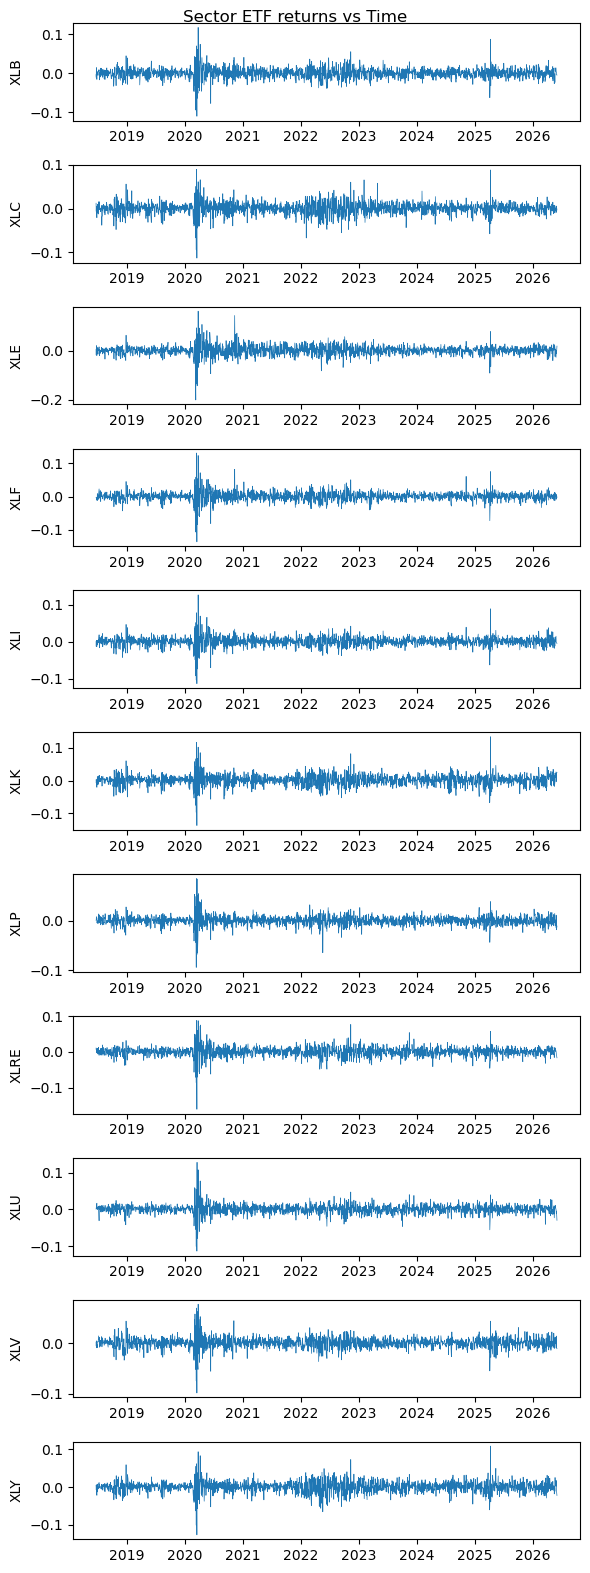

In [4]:
fig, axes = plt.subplots(11, 1, figsize = (6,16))
for i in range(11):
    axes[i].plot(returns.iloc[:,i], linewidth = 0.5)
    axes[i].set_ylabel(returns.columns[i])
fig.suptitle("Sector ETF returns vs Time")
plt.tight_layout()


In [5]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

returns_norm = StandardScaler().fit_transform(returns)
returns_norm

array([[-0.26690686,  0.84792981,  0.19008098, ...,  0.02482279,
         0.15668004,  0.27913374],
       [-0.79949172, -0.47819929, -0.94922332, ...,  0.22501023,
        -0.56267986, -0.50657898],
       [ 1.0174237 ,  0.2732789 ,  0.96195377, ...,  0.50041485,
         0.37318755, -0.14769572],
       ...,
       [ 0.22092538,  0.21247769, -0.06415828, ..., -0.9108945 ,
         1.24483447,  0.2429919 ],
       [-0.32749701, -0.64061371, -0.60507337, ..., -0.40085726,
        -0.88963752, -0.68049155],
       [-0.35690742, -0.0892423 ,  0.86217376, ..., -2.33579267,
        -1.03198772, -1.50320337]], shape=(1997, 11))

In [6]:
pca_object = PCA()
returns_pca = pca_object.fit_transform(returns_norm)
returns_pca

/opt/anaconda3/envs/COGS108_FA25/lib/python3.11/site-packages/sklearn/decomposition/_base.py:148: RuntimeWarning: divide by zero encountered in matmul
  X_transformed = X @ self.components_.T
/opt/anaconda3/envs/COGS108_FA25/lib/python3.11/site-packages/sklearn/decomposition/_base.py:148: RuntimeWarning: overflow encountered in matmul
  X_transformed = X @ self.components_.T
/opt/anaconda3/envs/COGS108_FA25/lib/python3.11/site-packages/sklearn/decomposition/_base.py:148: RuntimeWarning: invalid value encountered in matmul
  X_transformed = X @ self.components_.T


array([[ 0.55276129, -0.08762845, -0.42416375, ...,  0.18312067,
         0.03714397,  0.29079438],
       [-1.30063118,  0.98345993, -0.68922191, ..., -0.24470691,
        -0.23034045, -0.37382549],
       [ 1.13788901,  0.7802106 ,  0.61006541, ...,  0.85556317,
         0.13379621,  0.02903999],
       ...,
       [ 0.21260901, -0.90775455, -0.49009832, ...,  0.0340619 ,
         0.03906695, -0.26889574],
       [-1.39164348, -1.33047331,  0.00427891, ..., -0.40959603,
        -1.06143599, -0.60883757],
       [-1.78738545, -2.35128621,  1.02788938, ...,  0.14410527,
        -1.96400039, -0.19874658]], shape=(1997, 11))

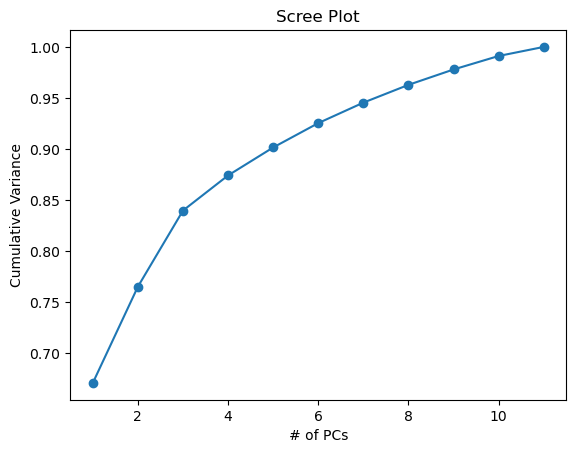

In [7]:
cum_var = np.cumsum(pca_object.explained_variance_ratio_)

plt.plot(range(1, len(cum_var)+1), cum_var, marker='o')
plt.title("Scree Plot")
plt.xlabel("# of PCs")
plt.ylabel("Cumulative Variance")
plt.show()

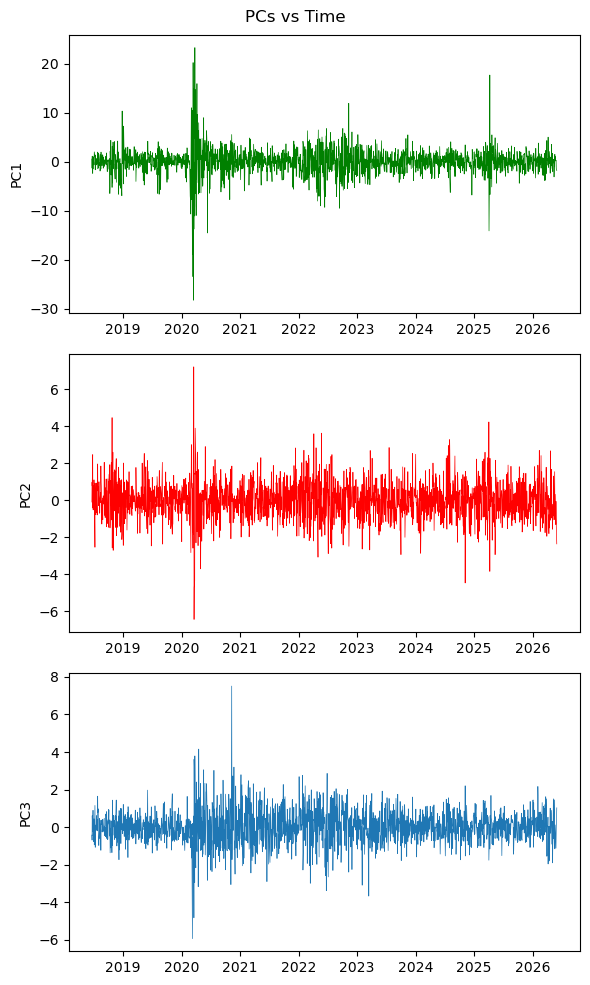

In [8]:
fig, axes = plt.subplots(3, 1, figsize = (6,10))
fig.suptitle("PCs vs Time")
axes[0].plot(returns.index, returns_pca[:,0], color = 'green', linewidth = 0.5)
axes[1].plot(returns.index, returns_pca[:,1], color = 'red', linewidth = 0.5)
axes[2].plot(returns.index, returns_pca[:,2], linewidth = 0.5)

axes[0].set_ylabel("PC1")
axes[1].set_ylabel("PC2")
axes[2].set_ylabel("PC3")
plt.tight_layout()

- All top 3 PCs reflect the market crash in early 2020, during the COVID-19 pandemic
- The top 2 PCs also reflect the downturns during the tariff issues in early 2025

In [9]:
pca_weights = pd.DataFrame(
    pca_object.components_.T,
    index=returns.columns,
    columns=[f"PC{i+1}" for i in range(len(returns.columns))]
)

tickers_to_sector = {
    "XLK": "Tech",
    "XLF": "Financials",
    "XLE": "Energy",
    "XLV": "Health",
    "XLI": "Industrials",
    "XLY": "Cons. Disc.",
    "XLP": "Cons. Staples",
    "XLB": "Materials",
    "XLU": "Utilities",
    "XLRE": "Real Estate",
    "XLC": "Comm. Services"
}

pca_weights = pca_weights.rename(index = tickers_to_sector)
pca_weights

,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,PC11
Ticker,,,,,,,,,,,
Materials,0.330325,-0.052556,0.200759,0.011811,-0.416421,0.044282,-0.179005,-0.282969,0.646798,0.094682,-0.364537
Comm. Services,0.298197,-0.335420,-0.308346,-0.017001,0.432625,0.142527,0.199514,0.419529,0.505637,0.030354,0.152728
Energy,0.241149,-0.096518,0.743796,0.028296,0.564168,-0.030012,0.067821,-0.214737,-0.078242,0.049728,0.002339
Financials,0.326029,-0.086878,0.267822,0.005513,-0.293884,0.083912,0.106285,0.659641,-0.323660,-0.161795,-0.378990
Industrials,0.339311,-0.084645,0.185061,-0.044519,-0.361564,0.010324,-0.190009,0.036915,-0.032405,-0.114833,0.811749
Tech,0.299818,-0.368320,-0.303220,-0.051812,0.162333,-0.135685,-0.390293,-0.280724,-0.230299,-0.560876,-0.190542
Cons. Staples,0.285519,0.414495,-0.144407,0.411102,0.071163,0.683434,0.107053,-0.188582,-0.099544,-0.166327,0.008479
Real Estate,0.304840,0.311381,-0.105493,-0.439022,-0.064516,-0.284382,0.645334,-0.209242,0.014938,-0.246395,0.006210
Utilities,0.260678,0.567751,-0.088029,-0.399098,0.244624,-0.061713,-0.533047,0.213631,-0.002271,0.217159,-0.045694


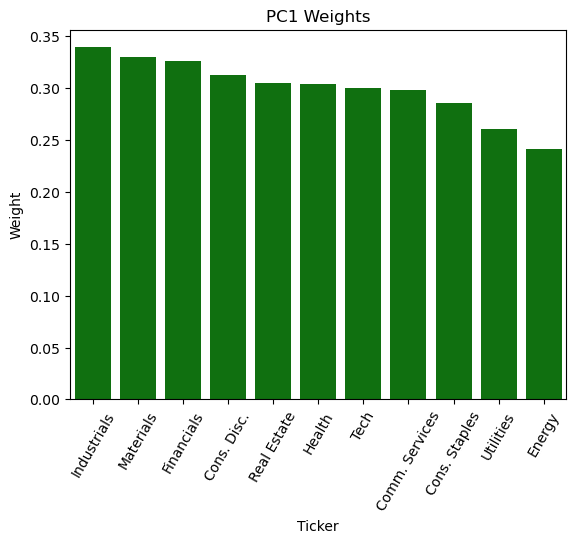

In [10]:
sns.barplot(pca_weights["PC1"].sort_values(ascending = False), color = 'green')
plt.title("PC1 Weights")
plt.ylabel("Weight")
plt.xticks(rotation = 60)
plt.show()

- PC1 corresponds to the entire market moving together

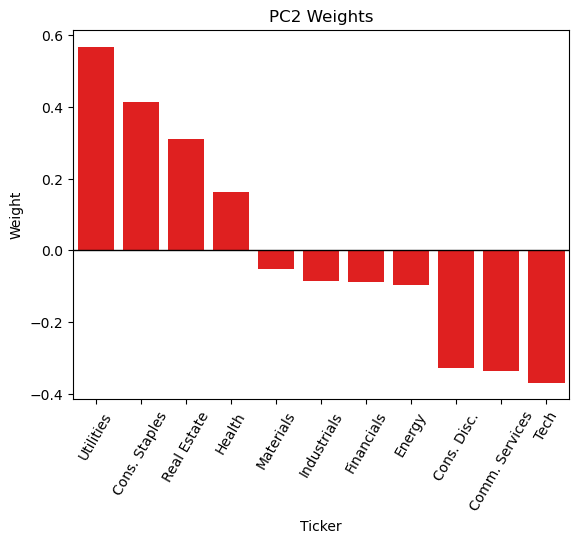

In [12]:
sns.barplot(pca_weights["PC2"].sort_values(ascending = False), color = 'red')
plt.title("PC2 Weights")
plt.ylabel("Weight")
plt.axhline(0, color="black", linewidth=1)
plt.xticks(rotation = 60)
plt.show()

- PC2 corresponds to the opposition between defensive/fundamental sectors and risky/discretionary sectors

In [ ]:
sns.barplot(pca_weights["PC3"].sort_values(ascending = False))
plt.title("PC3 Weights")
plt.ylabel("Weight")
plt.xticks(rotation = 60)
plt.axhline(0, color="black", linewidth=1)
plt.show()

- PC3 corresponds to energy having slight opposition to tech and communications

# Research Question
- Among macroeconomic indicators, sector performance, commodity prices, and investor sentiment, which factors are the most informative predictors of short-term movements in the S&P 500 Index (SPX), and can they be used to improve out-of-sample forecast performance?

# Methods
- PCA for data exploration
- Ridge Regression / LASSO
- Linear Regression

# Hypotheses
- Sector market data alone cannot improve SPX out-of-sample forcasts.
- Defensive sectors (utilities, consumer staples, )